## Выполнения заданий лабораторной работы 9. Вариант 2_1.
## Выполнил: Ибраев Дамир Беркутбаевич

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента – автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата – ответ на задание в LMS в виде двух файлов:
* ноутбук в формате **ipynb**, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате **html**, полученный путем экспорта ноутбука из п. 1.

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (ответов в текстовых ячейках, программного кода и комментариев к нему).   
   *  Ответы в текстовых ячейках на поставленные вопросы **обязательны для получения баллов** за проверочный тест.  
   *  Все выводимые на консоль значения должны быть **подписаны**.   
   *  Построенные графики должны быть хорошо читаемыми, иметь корректные названия и названия осей.   
    *  На графике с несколькими цветами **обязательна легенда** для идентификации каждого цвета.
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 9 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт библиотеки *NumPy* и модуля *Pyplot* библиотеки *Matplotlib*, а также подключить инструментарий для разбиения набора данных на обучающее/тестовое множество из библиотеки *Sciktit-learn*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Остальной необходимый для работы инструментарий подключать в тех кодовых ячейках, где он впервые используется.

### Задание 2

Сгенерировать модельный набор данных для задачи бинарной классификации по двум признакам, используя метод *make_classification*. При генерации задать:
*   общее количество объектов равным 170,
*   все признаки являются информативными,
*   нет линейно-зависимых признаков,
*   по одному облаку точек на каждый класс,
*   коэффициент, определяющий степень разделимости классов (*class_sep*), равный 0.9,
*   *random_state* равный 45.

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=170,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.9,
    random_state=45
)

Вывести сгенерированные значения признаков и метку класса для первых 10 объектов. Значения признаков округлить до 3 знаков после запятой.

In [3]:
for i in range(10):
    print(f"{np.round(X[i], 3)} -> class {y[i]}")

[-1.273  1.173] -> class 1
[-0.694 -0.939] -> class 0
[-0.034 -1.019] -> class 0
[-1.615  0.189] -> class 1
[-1.408  0.009] -> class 1
[-1.349 -0.665] -> class 1
[-0.66   1.396] -> class 1
[-2.026  0.31 ] -> class 1
[-1.457  1.1  ] -> class 1
[-1.141  1.111] -> class 1


Проверить сбалансированность классов в сгенерированном наборе, вычислив доли объектов, относящихся к каждому из классов.

In [4]:
unique, counts = np.unique(y, return_counts=True)

for cls, cnt in zip(unique, counts):
    print(f"Класс {cls}: {cnt} объектов ({cnt/len(y):.2f})")

Класс 0: 84 объектов (0.49)
Класс 1: 86 объектов (0.51)


Ответить на вопрос: является ли задача бинарной классификации сбалансированной или наблюдается дисбаланс классов?

__*Ваш ответ:*__ Задача является сбалансированной (доли классов близки к 0.5 / 0.5).



Выполнить визуализацию сгенерированного набора данных в виде диаграммы рассеяния, изобразив объекты, относящиеся к разным классам, разными цветами.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов можно оставить «по умолчанию» или же настроить свой, используя *ListedColormap*.

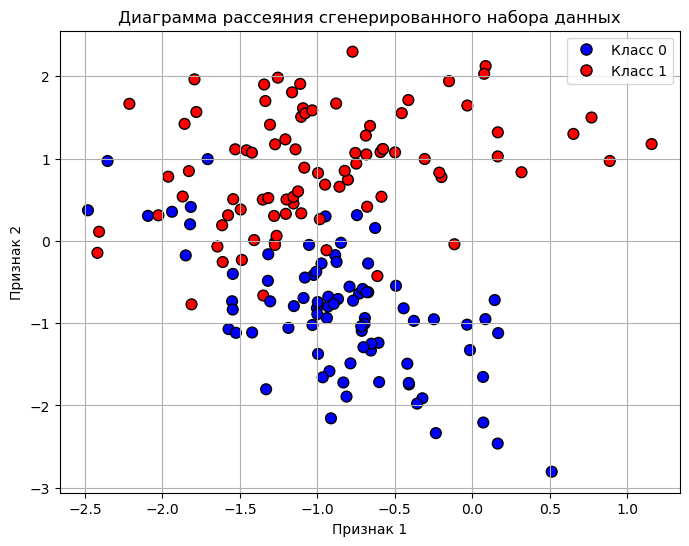

In [5]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['blue', 'red'])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='k', s=60)

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Диаграмма рассеяния сгенерированного набора данных')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 0',
               markerfacecolor='blue', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 1',
               markerfacecolor='red', markeredgecolor='k', markersize=8)
])

plt.grid(True)
plt.show()

По результатам визуализации ответить на вопросы:

* насколько хорошо визуально разделимы классы?

* можно ли провести прямую, которая разделяет два класса без ошибок? А с небольшим количеством ошибок?     
Если да, то как примерно ориентирована эта прямая (вертикально, горизонтально, под углом)?

* какой признак сильнее влияет на разделение классов?


__*Ваши ответы:*__

*   Классы визуально разделимы достаточно хорошо, но между ними есть зона частичного пересечения.

*   Идеально разделить классы одной прямой, скорее всего, нельзя, но провести прямую с небольшим числом ошибок можно. Такая прямая будет ориентирована примерно под углом.

*   На разделение классов сильнее влияет тот признак, вдоль которого визуально заметнее смещение облаков точек. В данной задаче это нужно окончательно определить по построенному графику. Вопросы такого типа прямо указаны в лабораторной.



### Задание 3

Выполнить разбиение сгенерированного набора данных на обучающую и тестовую выборки в соотношении 75/25. При разбиении задать *random_state* = 45.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=45
)

Вывести для ознакомления информацию о полученных выборках:
*   определить количество объектов в обучающей и тестовой выборках;
*   проверить баланс классов в обучающей и тестовой выборках, определив доли каждого класса. Полученные значения округлить до 3 знаков после запятой.



In [7]:
print(f"Обучающая выборка: {len(X_train)} объектов")
print(f"Тестовая выборка: {len(X_test)} объектов")

Обучающая выборка: 127 объектов
Тестовая выборка: 43 объектов


In [8]:
def print_balance(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{name}:")
    for cls, cnt in zip(unique, counts):
        print(f"Класс {cls}: {cnt} ({cnt/len(y):.3f})")

print_balance(y_train, "Обучающая выборка")
print_balance(y_test, "Тестовая выборка")


Обучающая выборка:
Класс 0: 61 (0.480)
Класс 1: 66 (0.520)

Тестовая выборка:
Класс 0: 23 (0.535)
Класс 1: 20 (0.465)


Ответить на вопрос: получившееся соотношение классов в обучающей и тестовой выборке близко к исходному соотношению классов в сгенерированном наборе данных или нет?

__*Ваш ответ:*__ Получившееся соотношение классов в обучающей и тестовой выборках близко к исходному. Существенного перекоса не наблюдается.



**Замечание**. В общем случае перед обучением линейного классификатора требуется провести масштабирование числовых признаков. Однако в данных, сгенерированных таким образом с помощью *make_classification*, признаки уже имеют сопоставимые масштабы и близкие характеристики разброса, поэтому в данном случае масштабирование не требуется.

### Задание 4

Импортировать инструментарий, необходимый для построения модели линейной классификации с применением $L_2$-регуляризации. Создать модель с параметрами по умолчанию и обучить ее на обучающей выборке.

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Получить коэффициенты обученной модели. Вывести полученные значения, округлив их до 2 знаков после запятой.

**Указание**. Не забыть про свободный коэффициент модели.

In [11]:
w = model.coef_[0]
w0 = model.intercept_[0]

print(f"w1 = {w[0]:.2f}")
print(f"w2 = {w[1]:.2f}")
print(f"w0 = {w0:.2f}")

w1 = -0.34
w2 = 2.61
w0 = -0.23


Записать уравнение обученной модели линейного классификатора в формате $a(x) = \DeclareMathOperator{\sign}{sign} \sign \left (w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 \right )$.   

Проверить, подтвердилось ли сделанное в задании 2 предположение о том, какой признак сильнее влияет на разделение классов.

__*Ваш ответ:*__ $a(x) = \DeclareMathOperator{\sign}{sign} \sign \left (-0.23 - 0.34 \cdot x^1 + 2.61 \cdot x^2 \right )$

Более сильное влияние оказывает признак с большим по модулю коэффициентом.

**Вопрос 4 в тесте**

Чему равен вес первого признака в обученной модели линейного классификатора?

Ввести значение с точностью до 2 знаков после запятой.

Вывести объект обучающей выборки с индексом 21, округлив значения признаков до 2 знаков после запятой.

In [14]:
x_sample = X_train[21]
print(np.round(x_sample, 2))

[-0.98  0.26]


Используя записанную формулу обученной модели линейного классификатора, определить предсказание модели для данного объекта «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

Подставим значения признаков объекта в уравнение обученной модели: a(x)=sign(−0.23−0.34x1​+2.61x2​)

Для объекта с индексом 21: x1 = -0.97, x2 = 0.26

Тогда: z=−0.23−0.34⋅(−0.98)+2.61⋅0.26−0.34⋅(−0.98)=0.3332−0.34⋅(−0.98)=0.3332

2.61⋅0.26=0.6786

z=−0.23+0.3332+0.6786 = 0.7818

__*Ответ:*__ Так как z>0, модель относит объект к классу 1.

Выполнить визуализацию разделяющей прямой линейного классификатора и обучающей выборки.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов должен остаться таким же, что и в задании 2.

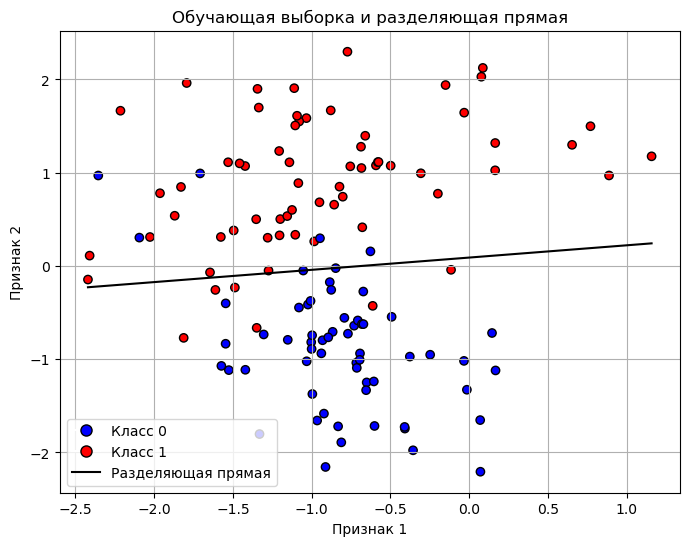

In [38]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['blue', 'red'])

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, edgecolors='k')

x_vals = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
y_vals = -(w0 + w[0]*x_vals) / w[1]

plt.plot(x_vals, y_vals, color='black', label='Разделяющая прямая')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Обучающая выборка и разделяющая прямая')

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 0',
               markerfacecolor='blue', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 1',
               markerfacecolor='red', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], color='black', label='Разделяющая прямая')
])

plt.grid()
plt.show()

Ответить на вопросы:
*   сколько объектов класса 0 в обучающей выборке были отнесены моделью к классу 1?
*   сколько объектов класса 1 в обучающей выборке были отнесены моделью к классу 0?

In [28]:
y_pred_train = model.predict(X_train)

errors_0_to_1 = np.sum((y_train == 0) & (y_pred_train == 1))
errors_1_to_0 = np.sum((y_train == 1) & (y_pred_train == 0))

print(errors_0_to_1, errors_1_to_0)

5 6


__*Ваши ответы:*__

*   Количество объектов класса 0, ошибочно отнесённых к 1: 5
*   Количество объектов класса 1, ошибочно отнесённых к 0: 6




### Задание 5

Выполнить визуализацию разделяющей прямой линейного классификатора и тестовой выборки.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов должен остаться таким же, что и в задании 2.

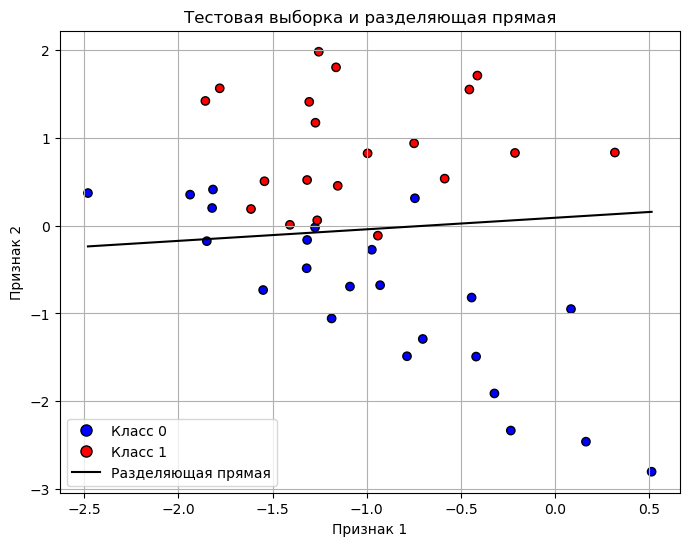

In [39]:
cmap = ListedColormap(['blue', 'red'])

plt.figure(figsize=(8, 6))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap, edgecolors='k')

x_vals = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100)
y_vals = -(w0 + w[0]*x_vals) / w[1]

plt.plot(x_vals, y_vals, color='black', label='Разделяющая прямая')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Тестовая выборка и разделяющая прямая')

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 0',
               markerfacecolor='blue', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Класс 1',
               markerfacecolor='red', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], color='black', label='Разделяющая прямая')
])



plt.grid()
plt.show()

Ответить на вопросы:
*   сколько объектов класса 0 в тестовой выборке модель определит как объекты класса 1?
*   сколько объектов класса 1 в тестовой выборке модель определит как объекты класса 0?

In [40]:
y_pred_test = model.predict(X_test)

errors_0_to_1 = np.sum((y_test == 0) & (y_pred_test == 1))
errors_1_to_0 = np.sum((y_test == 1) & (y_pred_test == 0))

print(f"0 → 1: {errors_0_to_1}")
print(f"1 → 0: {errors_1_to_0}")

0 → 1: 6
1 → 0: 1


__*Ваши ответы:*__

*   Объекты класса 0 → 1: 6
*   Объекты класса 1 → 0: 1



Получить и визуализировать матрицу ошибок классификатора на обучающей выборке.

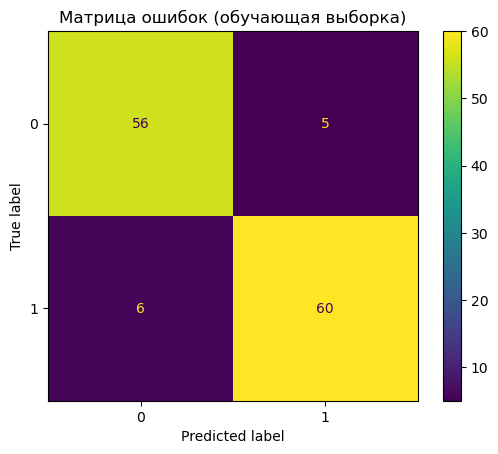

TP = 60
FP = 5
TN = 56
FN = 6


In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_train = model.predict(X_train)

cm = confusion_matrix(y_train, y_pred_train)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Матрица ошибок (обучающая выборка)")
plt.show()

TN, FP, FN, TP = cm.ravel()

print("TP =", TP)
print("FP =", FP)
print("TN =", TN)
print("FN =", FN)

По построенной визуализации матрицы ошибок определите количество объектов обучающей выборки, относящихся к каждой из 4 групп: *true positive*, *false positive*, *true negative* и *false negative*.

__*Ваш ответ:*__

*   $TP = $ $60$

*   $FP = $ $5$

*   $TN = $ $56$

*   $FN = $ $6$



Соотнести полученные значения в матрице с результатами визуализации.

Получить и визуализировать матрицу ошибок  обученного классификатора на тестовой выборке. Соотнести значения в матрице с результатами визуализации.

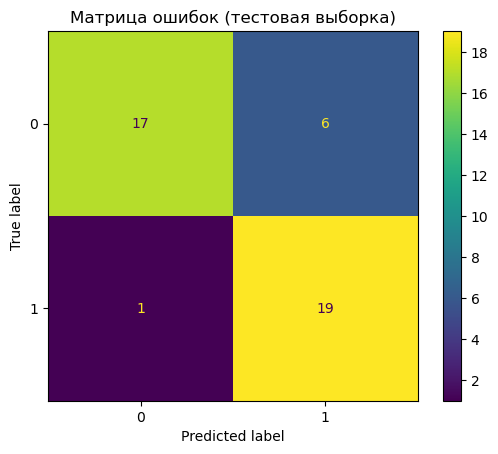

In [47]:
y_pred_test = model.predict(X_test)

cm_test = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot()

plt.title("Матрица ошибок (тестовая выборка)")
plt.show()

### Задание 6

Используя матрицу ошибок на тестовой выборке, «вручную» (по формулам) вычислить долю правильных ответов, точность, полноту и *F*-меру.

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

__*Ваш ответ:*__ 

- \( accuracy = 0.837 \)
- \( precision = 0.760 \)
- \( recall = 0.950 \)
- \( F1 = 0.845 \)

Используем значения из матрицы ошибок:

\[TP = 19,\quad FP = 6,\quad TN = 17,\quad FN = 1\]

Общее количество объектов:

\[
N = TP + TN + FP + FN = 19 + 17 + 6 + 1 = 43
\]

---

### 1. Accuracy (доля правильных ответов)

accuracy=(19+17)/43=0.837

---

### 2. Precision (точность)

precision=19/25=0.760

---

### 3. Recall (полнота)

recall=19/20=0.950

---

### 4. F1-мера

F1=20⋅0.760+0.950/0.760+0.950 = 0.845

---

Используя инструментарий модуля *sklearn.metrics*, найти значения метрик  *accuracy*, *precision*, *recall* и *F-меры* на обучающей выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_train = model.predict(X_train)

print(f"accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"precision: {precision_score(y_train, y_pred_train):.3f}")
print(f"recall: {recall_score(y_train, y_pred_train):.3f}")
print(f"f1: {f1_score(y_train, y_pred_train):.3f}")

accuracy: 0.913
precision: 0.923
recall: 0.909
f1: 0.916


Найти значения метрик  *accuracy*, *precision*, *recall* и *F-меры* на тестовой выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [49]:
y_pred_test = model.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, y_pred_test):.3f}")
print(f"precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"recall: {recall_score(y_test, y_pred_test):.3f}")
print(f"f1: {f1_score(y_test, y_pred_test):.3f}")

accuracy: 0.837
precision: 0.760
recall: 0.950
f1: 0.844


Сопоставить найденные значения метрик на тестовой выборке с результатами вычислений «вручную».

Дать интерпретацию полученным значениям метрик на тестовой выборке (с пояснением того, какую величину измеряет каждая метрика).

__*Ваши ответы:*__

*   Accuracy — доля правильных ответов модели

*   Precision — точность положительных предсказаний (насколько “чистые” предсказания класса 1)

*   Recall — полнота (насколько хорошо модель находит все объекты класса 1)

*   F1 — баланс между precision и recall

Сделать вывод о качестве классификации полученной модели.

__*Ваш ответ:*__

Полученная модель линейной классификации демонстрирует достаточно высокое качество. На тестовой выборке значение accuracy составляет 0.837, что свидетельствует о правильной классификации большинства объектов. Значение полноты (recall = 0.950) показывает, что модель эффективно выявляет объекты положительного класса и практически не пропускает их. Однако точность (precision = 0.760) ниже, что указывает на наличие ложноположительных предсказаний. Значение F1-меры (0.844) подтверждает, что модель обеспечивает сбалансированное качество классификации. В целом, модель можно считать эффективной, однако она склонна к некоторому числу ложных срабатываний.

